In [ ]:
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
rfm = '''WITH order_value AS (SELECT order_id,SUM(payment_value) AS payment
                                          FROM order_payments
                                          GROUP BY order_id) 
        SELECT c.customer_unique_id AS customer, COUNT(o.order_id) AS frequency, SUM(ov.payment) AS monetary_value,
               MAX(o.order_purchase_timestamp) AS last_order_date
                    FROM orders AS o
                    INNER JOIN order_value AS ov
                    ON o.order_id = ov.order_id
                    INNER JOIN customers AS c
                    ON o.customer_id = c.customer_id
                    WHERE o.order_status != 'canceled'
                    GROUP BY c.customer_unique_id; 
                 ''' 
rfm_df = pd.read_sql(rfm,engine)

sql query to grab the required columns

In [3]:
ref_date = rfm_df['last_order_date'].max()
rfm_df['recency'] = (ref_date - rfm_df['last_order_date']).dt.days
rfm_df.drop('last_order_date',axis=1,inplace=True)

This will give us the Recency


In [4]:
rfm_df['R'] = pd.qcut(rfm_df['recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1])
rfm_df['F'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_df['M'] = pd.qcut(rfm_df['monetary_value'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_df.drop(['frequency','recency','monetary_value'],axis=1,inplace=True)


In [5]:
def customer_rank(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Somewhat loyal'
    elif r == 2 and f >= 3:
        return 'At risk'
    elif r < 2 and f >= 3:
        return 'Cannot lose them'
    else:
        return 'Lost'

rfm_df['Segment'] = rfm_df.apply(customer_rank, axis=1)
rfm_seg = rfm_df.groupby('Segment').agg(customer_count = ('customer','count')).reset_index().sort_values('customer_count',ascending=False)

Now we have the RFM Segmentation dataframe 


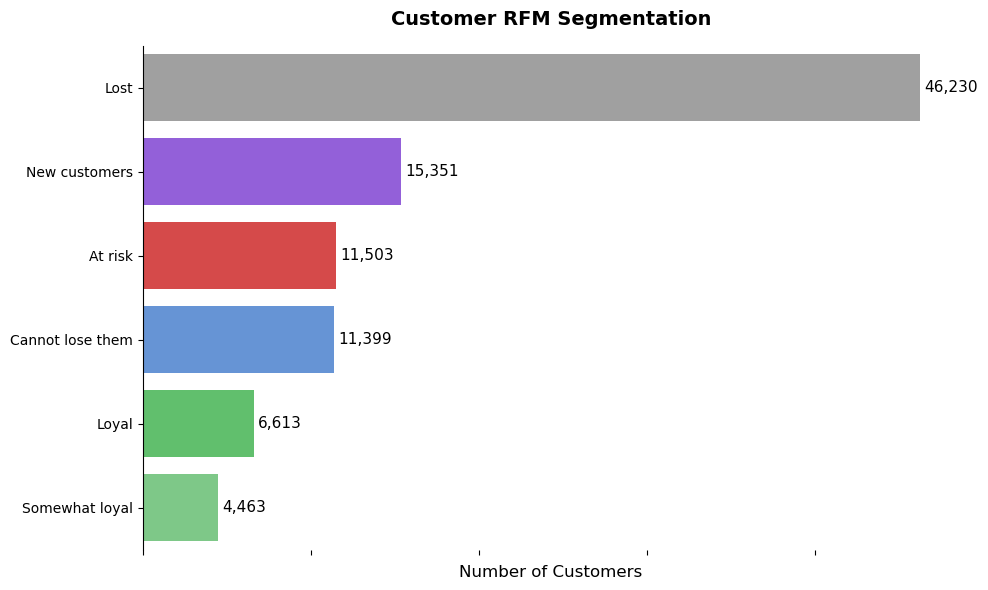

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
custom_colors =["#A0A0A0",  
    "#904CED","#ec3333",  
    "#5491E7",  
    "#51CF61",   
    "#72D47F",]
sns.barplot(x='customer_count', y='Segment',hue='Segment',data=rfm_seg,palette=custom_colors,legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt="{:,.0f}", padding=3, fontsize=11)
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_ylabel('')
ax.set_title('Customer RFM Segmentation', fontsize=14, weight='bold', pad=15)
ax.set_xticklabels([])
sns.despine(bottom=True)
plt.tight_layout()
plt.show()

One interesting fact worth noting is that "Lost" customers here are more or less the customers who didn't have a reason to come back since Olist sells goods people don't buy every year so the customer base is one-time purchase dominant. This fact is also backed by a 97% single-order rate. <br>The focus here should be at the "At risk" and "Cannot lose them" segments as these are the customers who are repeat buyers showing signs of drop-off.

In [8]:
# Exporting dataframe to csv for use in Tableau
rfm_seg.to_csv('/Volumes/Air/Olist_exports_tableau/RFM_segmentation.csv', index=False)

In [8]:
# Exporting dataframe to csv for use in Tableau
rfm_df.to_csv('/Volumes/Air/Olist_exports_tableau/customer.csv', index=False)